In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
import numpy as np
from scipy import stats
import os
import smarts_cerebellum.globals as gl

In [15]:
atlas = 'Nettekoven2024'
rois  = gl.rois[atlas]
colours = ['green', 'r', 'blue']

GM  = pd.read_csv(os.path.join(gl.baseDir, 'regression', 'summary_MNISymC_Nettekoven_2024_GM_mod_slope.tsv'), sep = '\t')
GM = GM.groupby(['subj_id', 'regionname', 'group']).mean(numeric_only=True).reset_index()

KeyError: 'group'

ValueError: Could not interpret value `group` for `x`. An entry with this name does not appear in `data`.

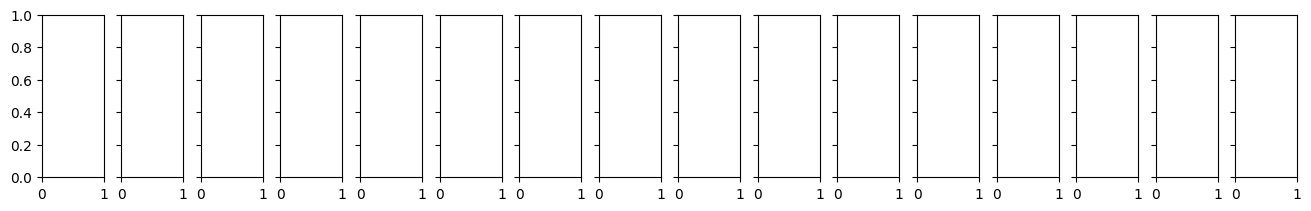

In [ ]:
colours = ['green', 'r', 'blue']

fig, axs = plt.subplots(1, len(rois), figsize=(13, 2), sharex=True, sharey=True, constrained_layout=True)

for r, roi in enumerate(rois):
    ax = axs[r]
    #sns.boxplot(data=GM[GM.regionname==roi], ax=ax, hue='group', y='mean', showfliers=False, legend=r==len(rois)-1, palette = colours)
    #sns.pointplot(data=GM[GM.regionname == roi], ax = ax, y='mean', hue = 'group', errorbar='se', dodge=.55, legend=False, palette = colours)
    #sns.violinplot(data=GM[GM.regionname == roi], ax = ax, y='mean', hue = 'group', legend=False, palette = colours)
    sns.stripplot(data=GM[GM.regionname == roi], ax = ax, y='mean', x = 'group', legend=False, palette = colours)


    ax.set_title(roi)
    ax.axhline(0, ls='-', lw=.8, color='k')
    
axs[-1].legend(loc='center left', bbox_to_anchor=(1, .5))
ax.set_xticks([])

for i in range(1, len(rois)):
    axs[i].tick_params(axis = 'y', length = 0)

fig.savefig('figure/GMV_Nettekoven2024.pdf')

plt.show()

In [6]:
for roi in rois:
    print(f'---t-tests for {roi}---')
    t_val, p_val = stats.ttest_ind(GM[(GM.group=='ipsilesional') & (GM.regionname==roi)]['mean'], GM[(GM.group=='controls') & (GM.regionname==roi)]['mean'])
    print(f'**t-test for WM {roi}: lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
    print('\n')

    t_val, p_val = stats.ttest_ind(GM[(GM.group=='contralesional') & (GM.regionname==roi)]['mean'], GM[(GM.group=='controls') & (GM.regionname==roi)]['mean'])
    print(f'**t-test for WM {roi}: non-lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
    print('\n')

    t_val, p_val = stats.ttest_rel(GM[(GM.group=='contralesional') & (GM.regionname==roi)]['mean'], GM[(GM.group=='ipsilesional') & (GM.regionname==roi)]['mean'])
    print(f'**t-test for WM {roi}: within patients, left, right hemispheres** \n t-value: {t_val} \t p-value: {p_val}')
    print('\n')



---t-tests for M1---
**t-test for WM M1: lesion side in patients, controls** 
 t-value: -1.279683952142242 	 p-value: 0.20736296012640137


**t-test for WM M1: non-lesion side in patients, controls** 
 t-value: -1.5774749494435412 	 p-value: 0.12184967585845224


**t-test for WM M1: within patients, left, right hemispheres** 
 t-value: -1.5113329369131143 	 p-value: 0.13968074768126434


---t-tests for M2---
**t-test for WM M2: lesion side in patients, controls** 
 t-value: -0.8586321951491714 	 p-value: 0.3951970292073018


**t-test for WM M2: non-lesion side in patients, controls** 
 t-value: -1.2787188917025607 	 p-value: 0.2076996389436706


**t-test for WM M2: within patients, left, right hemispheres** 
 t-value: -3.4547994820854173 	 p-value: 0.0014603750828704248


---t-tests for M3---
**t-test for WM M3: lesion side in patients, controls** 
 t-value: -1.0168308697552397 	 p-value: 0.314792764581838


**t-test for WM M3: non-lesion side in patients, controls** 
 t-value: -1.7747